# Mini-SWE-Agent Parallel Sweep Resource Analysis

This notebook summarizes the batch sweep outputs under `benchmark_results/parallel_sweep_*`.

Each batch directory contains one result JSON per agent/job:

```text
batch_8/job_1/sorting_benchmark.json
batch_8/job_2/sorting_benchmark.json
...
```

The notebook builds one per-job table, then gives two batch-level views:

1. **Average view**: mean metric across all jobs in a batch.
2. **Maximum view**: maximum observed metric across all jobs in a batch.

Use the average view for typical per-agent behavior. Use the maximum view for capacity planning and peak resource pressure. GPU metrics are sampled at machine/GPU level during each job window, so concurrent jobs observe shared GPU load rather than isolated per-agent GPU ownership.

In [2]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["font.size"] = 10

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BENCH_DIR = REPO_ROOT / "benchmark_results"

# Set this to a specific sweep if needed. If None, the latest parallel_sweep* dir is used.
SWEEP_DIR = "benchmark_results/parallel_sweep_full_20260510_194911"

sweep_candidates = sorted(
    [p for p in BENCH_DIR.glob("parallel_sweep*") if p.is_dir()],
    key=lambda p: p.stat().st_mtime,
)
if SWEEP_DIR is None:
    if not sweep_candidates:
        raise FileNotFoundError(f"No parallel sweep directories found under {BENCH_DIR}")
    SWEEP_DIR = sweep_candidates[-1]
else:
    SWEEP_DIR = Path(SWEEP_DIR)
    if not SWEEP_DIR.is_absolute():
        SWEEP_DIR = REPO_ROOT / SWEEP_DIR

print("repo root:", REPO_ROOT)
print("benchmark dir:", BENCH_DIR)
print("sweep dir:", SWEEP_DIR)

repo root: /home/jwang354/cpu-centric-agentic-ai/mini-swe-agent
benchmark dir: /home/jwang354/cpu-centric-agentic-ai/mini-swe-agent/benchmark_results
sweep dir: /home/jwang354/cpu-centric-agentic-ai/mini-swe-agent/benchmark_results/parallel_sweep_full_20260510_194911


## Load Batch JSON Files

The loader flattens each `sorting_benchmark.json` into one row. It keeps top-level timing metrics plus run-level and per-stage resource metrics.

In [3]:
STAGE_NAMES = ("llm_api", "bash_execution", "agent_overhead")
RESOURCE_KEYS = (
    "cpu_max_percent",
    "memory_max_bytes",
    "memory_max_percent",
    "gpu_max_percent",
    "vram_max_bytes",
    "disk_read_bytes_total",
    "disk_write_bytes_total",
    "disk_read_peak_mbps",
    "disk_write_peak_mbps",
    "net_sent_bytes_total",
    "net_recv_bytes_total",
    "net_sent_peak_mbps",
    "net_recv_peak_mbps",
    "sample_count",
)


def batch_num(path: Path) -> int:
    match = re.search(r"batch_(\d+)", str(path))
    return int(match.group(1)) if match else -1


def job_num(path: Path) -> int:
    match = re.search(r"job_(\d+)", str(path))
    return int(match.group(1)) if match else -1


def bytes_to_gib(value):
    if value is None or pd.isna(value):
        return np.nan
    return value / (1024 ** 3)


def bytes_to_mib(value):
    if value is None or pd.isna(value):
        return np.nan
    return value / (1024 ** 2)


def safe_get(mapping, key, default=np.nan):
    value = mapping.get(key, default) if isinstance(mapping, dict) else default
    return np.nan if value is None else value


def flatten_result(path: Path) -> dict:
    doc = json.loads(path.read_text())
    usage = doc.get("usage_time_by_stage", {}) or {}
    timing = doc.get("timing_summary", {}) or {}
    run_metrics = usage.get("resource_metrics") or doc.get("resource_metrics") or {}
    stages = usage.get("stages", {}) or {}

    row = {
        "batch_size": batch_num(path),
        "job_id": job_num(path),
        "path": str(path.relative_to(REPO_ROOT)),
        "exit_status": doc.get("exit_status"),
        "total_runtime_s": doc.get("total_runtime") or usage.get("total_runtime_seconds"),
        "total_wall_time_s": doc.get("total_wall_time") or doc.get("total_runtime"),
        "model_calls": doc.get("model_calls", np.nan),
        "model_cost": doc.get("model_cost", np.nan),
        "llm_time_s": timing.get("total_llm_time_seconds", np.nan),
        "bash_time_s": timing.get("total_bash_time_seconds", np.nan),
        "agent_overhead_s": timing.get("other_time_seconds", np.nan),
        "llm_calls": timing.get("total_llm_calls", np.nan),
        "bash_calls": timing.get("total_bash_calls", np.nan),
    }

    for key in RESOURCE_KEYS:
        row[f"run_{key}"] = safe_get(run_metrics, key)

    row["run_memory_max_gib"] = bytes_to_gib(row["run_memory_max_bytes"])
    row["run_vram_max_gib"] = bytes_to_gib(row["run_vram_max_bytes"])
    row["run_disk_read_mib"] = bytes_to_mib(row["run_disk_read_bytes_total"])
    row["run_disk_write_mib"] = bytes_to_mib(row["run_disk_write_bytes_total"])
    row["run_net_sent_mib"] = bytes_to_mib(row["run_net_sent_bytes_total"])
    row["run_net_recv_mib"] = bytes_to_mib(row["run_net_recv_bytes_total"])

    for stage in STAGE_NAMES:
        stage_data = stages.get(stage, {}) or {}
        stage_metrics = stage_data.get("resource_metrics", {}) or {}
        row[f"{stage}_duration_s"] = safe_get(stage_data, "duration_seconds", 0.0)
        row[f"{stage}_runtime_pct"] = safe_get(stage_data, "percentage_of_runtime", np.nan)
        for key in RESOURCE_KEYS:
            row[f"{stage}_{key}"] = safe_get(stage_metrics, key)
        row[f"{stage}_memory_max_gib"] = bytes_to_gib(row[f"{stage}_memory_max_bytes"])
        row[f"{stage}_vram_max_gib"] = bytes_to_gib(row[f"{stage}_vram_max_bytes"])
        row[f"{stage}_disk_read_mib"] = bytes_to_mib(row[f"{stage}_disk_read_bytes_total"])
        row[f"{stage}_disk_write_mib"] = bytes_to_mib(row[f"{stage}_disk_write_bytes_total"])
        row[f"{stage}_net_sent_mib"] = bytes_to_mib(row[f"{stage}_net_sent_bytes_total"])
        row[f"{stage}_net_recv_mib"] = bytes_to_mib(row[f"{stage}_net_recv_bytes_total"])

    return row


result_files = sorted(SWEEP_DIR.glob("batch_*/job_*/sorting_benchmark.json"), key=lambda p: (batch_num(p), job_num(p)))
if not result_files:
    raise FileNotFoundError(f"No sorting_benchmark.json files found under {SWEEP_DIR}")

jobs_df = pd.DataFrame([flatten_result(path) for path in result_files]).sort_values(["batch_size", "job_id"])

print(f"loaded {len(jobs_df)} job result files")
print("batches:", sorted(jobs_df["batch_size"].unique()))
jobs_df[["batch_size", "job_id", "exit_status", "total_runtime_s", "llm_time_s", "bash_time_s", "run_gpu_max_percent", "run_vram_max_gib"]].head(10)

loaded 255 job result files
batches: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64), np.int64(128)]


,batch_size,job_id,exit_status,total_runtime_s,llm_time_s,bash_time_s,run_gpu_max_percent,run_vram_max_gib
0,1,1,Submitted,43.300919,21.504668,21.785049,98.0,72.66803
1,2,1,Submitted,43.089285,20.764673,22.313970,98.0,72.66803
2,2,2,Submitted,42.588568,20.750129,21.825217,98.0,72.66803
3,4,1,Submitted,42.952410,20.961080,21.980534,98.0,72.66803
4,4,2,Submitted,42.658806,21.035807,21.611995,98.0,72.66803
5,4,3,Submitted,39.485619,17.983463,21.488690,98.0,72.66803
6,4,4,Submitted,39.611758,17.992026,21.607769,98.0,72.66803
7,8,1,Submitted,40.095291,18.361980,21.721158,98.0,72.66803
8,8,2,Submitted,43.340717,21.553591,21.775614,98.0,72.66803
9,8,3,Submitted,43.766729,21.530706,22.224070,98.0,72.66803


## Load Batch Wall-Time Summaries

`batch_summary.txt` gives the elapsed wall-clock time for the entire concurrent batch. This is different from each agent's own runtime because all jobs in a batch run at the same time.

In [4]:
def parse_batch_summary(path: Path) -> dict:
    text = path.read_text().strip()
    row = {"batch_size": batch_num(path), "summary_path": str(path.relative_to(REPO_ROOT)), "raw_summary": text}
    for key, value in re.findall(r"(\w+)=([^\s]+)", text):
        if key in {"batch_size", "duration_seconds", "result_files"}:
            row[key] = int(float(value))
        else:
            row[key] = value
    return row

summary_files = sorted(SWEEP_DIR.glob("batch_*/batch_summary.txt"), key=batch_num)
batch_wall_df = pd.DataFrame([parse_batch_summary(p) for p in summary_files]).sort_values("batch_size")

expected_counts = jobs_df.groupby("batch_size").size().rename("loaded_result_files").reset_index()
batch_wall_df = batch_wall_df.merge(expected_counts, on="batch_size", how="outer").sort_values("batch_size")
batch_wall_df["throughput_jobs_per_s"] = batch_wall_df["loaded_result_files"] / batch_wall_df["duration_seconds"]
batch_wall_df

,batch_size,summary_path,raw_summary,status,duration_seconds,result_files,submitted,loaded_result_files,throughput_jobs_per_s
0,1,benchmark_results/parallel_sweep_full_20260510...,batch_size=1 status=0 duration_seconds=44 resu...,0,44,1,1,1,0.022727
1,2,benchmark_results/parallel_sweep_full_20260510...,batch_size=2 status=0 duration_seconds=44 resu...,0,44,2,2,2,0.045455
2,4,benchmark_results/parallel_sweep_full_20260510...,batch_size=4 status=0 duration_seconds=44 resu...,0,44,4,4,4,0.090909
3,8,benchmark_results/parallel_sweep_full_20260510...,batch_size=8 status=0 duration_seconds=46 resu...,0,46,8,8,8,0.173913
4,16,benchmark_results/parallel_sweep_full_20260510...,batch_size=16 status=0 duration_seconds=865 re...,0,865,16,6,16,0.018497
5,32,benchmark_results/parallel_sweep_full_20260510...,batch_size=32 status=0 duration_seconds=47 res...,0,47,32,32,32,0.680851
6,64,benchmark_results/parallel_sweep_full_20260510...,batch_size=64 status=0 duration_seconds=210 re...,0,210,64,63,64,0.304762
7,128,benchmark_results/parallel_sweep_full_20260510...,batch_size=128 status=0 duration_seconds=236 r...,0,236,128,128,128,0.542373


## Sanity Checks

Confirm every batch has the expected number of result files and completed jobs.

In [5]:
status_by_batch = (
    jobs_df.assign(completed=jobs_df["exit_status"].eq("Submitted"))
    .groupby("batch_size")
    .agg(
        jobs=("job_id", "count"),
        submitted=("completed", "sum"),
        failed=("completed", lambda s: int((~s).sum())),
        min_runtime_s=("total_runtime_s", "min"),
        max_runtime_s=("total_runtime_s", "max"),
    )
    .reset_index()
)
status_by_batch.merge(batch_wall_df[["batch_size", "duration_seconds", "throughput_jobs_per_s"]], on="batch_size", how="left")

,batch_size,jobs,submitted,failed,min_runtime_s,max_runtime_s,duration_seconds,throughput_jobs_per_s
0,1,1,1,0,43.300919,43.300919,44,0.022727
1,2,2,2,0,42.588568,43.089285,44,0.045455
2,4,4,4,0,39.485619,42.952410,44,0.090909
3,8,8,8,0,39.761746,44.547023,46,0.173913
4,16,16,6,10,341.160929,863.546420,865,0.018497
5,32,32,32,0,41.752918,45.674572,47,0.680851
6,64,64,63,1,101.708853,207.348828,210,0.304762
7,128,128,128,0,155.834166,232.348759,236,0.542373


# Solution 1: Average Across Jobs

This view answers: *what did a typical agent/job in this batch observe?*

In [6]:
avg_cols = [
    "total_runtime_s",
    "llm_time_s",
    "bash_time_s",
    "agent_overhead_s",
    "model_calls",
    "llm_calls",
    "bash_calls",
    "run_cpu_max_percent",
    "run_memory_max_gib",
    "run_memory_max_percent",
    "run_gpu_max_percent",
    "run_vram_max_gib",
    "run_disk_read_mib",
    "run_disk_write_mib",
    "run_disk_read_peak_mbps",
    "run_disk_write_peak_mbps",
    "run_net_sent_mib",
    "run_net_recv_mib",
    "run_net_sent_peak_mbps",
    "run_net_recv_peak_mbps",
]

batch_avg = jobs_df.groupby("batch_size", as_index=False)[avg_cols].mean()
batch_avg = batch_avg.merge(
    batch_wall_df[["batch_size", "duration_seconds", "loaded_result_files", "throughput_jobs_per_s"]],
    on="batch_size",
    how="left",
)
batch_avg = batch_avg.rename(columns={
    "duration_seconds": "batch_wall_time_s",
    "loaded_result_files": "jobs",
})

avg_display_cols = [
    "batch_size", "jobs", "batch_wall_time_s", "throughput_jobs_per_s",
    "total_runtime_s", "llm_time_s", "bash_time_s",
    "run_gpu_max_percent", "run_vram_max_gib", "run_cpu_max_percent", "run_memory_max_gib",
]
batch_avg[avg_display_cols].round(3)

,batch_size,jobs,batch_wall_time_s,throughput_jobs_per_s,total_runtime_s,llm_time_s,bash_time_s,run_gpu_max_percent,run_vram_max_gib,run_cpu_max_percent,run_memory_max_gib
0,1,1,44,0.023,43.301,21.505,21.785,98.000,72.668,6.300,14.657
1,2,2,44,0.045,42.839,20.757,22.070,98.000,72.668,6.600,14.729
2,4,4,44,0.091,41.177,19.493,21.672,98.000,72.668,7.950,14.899
3,8,8,46,0.174,42.729,20.734,21.983,98.000,72.668,14.175,15.289
4,16,16,865,0.018,434.486,426.471,8.002,100.000,72.670,12.881,16.197
5,32,32,47,0.681,43.223,21.216,21.995,98.000,72.670,53.728,17.763
6,64,64,210,0.305,133.617,71.162,62.425,98.875,72.670,100.000,21.760
7,128,128,236,0.542,183.233,120.135,63.061,99.609,72.672,100.000,29.320


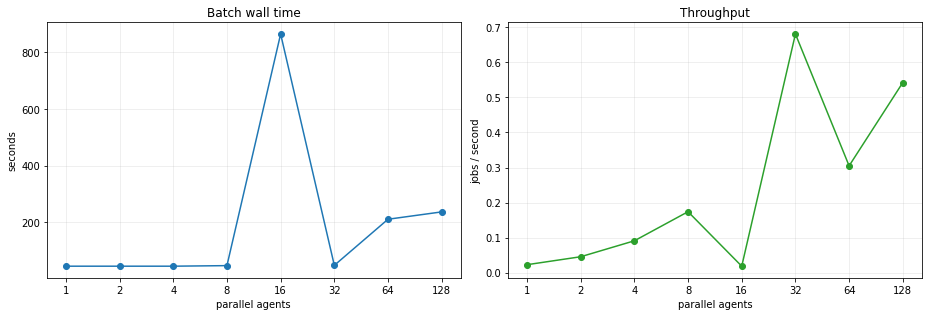

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(batch_avg["batch_size"], batch_avg["batch_wall_time_s"], marker="o", label="batch wall time")
axes[0].set_title("Batch wall time")
axes[0].set_xlabel("parallel agents")
axes[0].set_ylabel("seconds")
axes[0].set_xscale("log", base=2)
axes[0].set_xticks(batch_avg["batch_size"])
axes[0].set_xticklabels(batch_avg["batch_size"].astype(str))

axes[1].plot(batch_avg["batch_size"], batch_avg["throughput_jobs_per_s"], marker="o", color="tab:green")
axes[1].set_title("Throughput")
axes[1].set_xlabel("parallel agents")
axes[1].set_ylabel("jobs / second")
axes[1].set_xscale("log", base=2)
axes[1].set_xticks(batch_avg["batch_size"])
axes[1].set_xticklabels(batch_avg["batch_size"].astype(str))

fig.tight_layout()
plt.show()

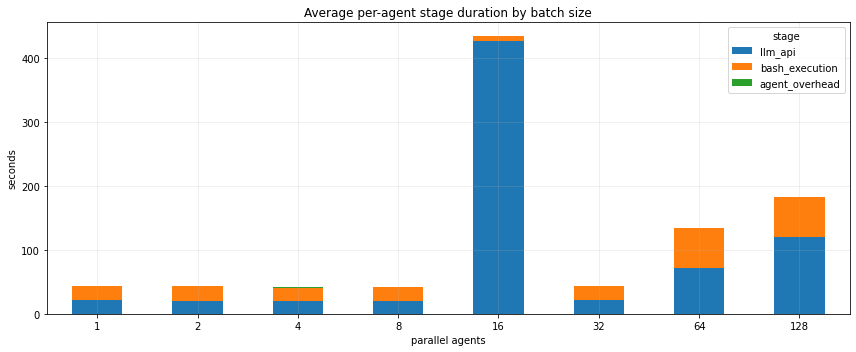

,llm_api,bash_execution,agent_overhead
batch_size,,,
1,21.505,21.785,0.011
2,20.757,22.070,0.012
4,19.493,21.672,0.012
8,20.734,21.983,0.012
16,426.471,8.002,0.013
32,21.216,21.995,0.013
64,71.162,62.425,0.029
128,120.135,63.061,0.037


In [8]:
stage_avg = jobs_df.groupby("batch_size")[[f"{s}_duration_s" for s in STAGE_NAMES]].mean()
stage_avg.columns = [c.replace("_duration_s", "") for c in stage_avg.columns]

ax = stage_avg.plot(kind="bar", stacked=True, figsize=(12, 5), color=["tab:blue", "tab:orange", "tab:green"])
ax.set_title("Average per-agent stage duration by batch size")
ax.set_xlabel("parallel agents")
ax.set_ylabel("seconds")
ax.legend(title="stage")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

stage_avg.round(3)

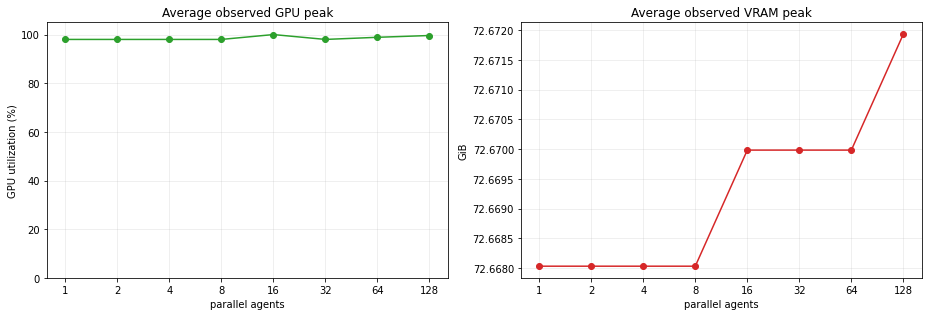

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(batch_avg["batch_size"], batch_avg["run_gpu_max_percent"], marker="o", color="tab:green", label="avg observed GPU peak")
axes[0].set_title("Average observed GPU peak")
axes[0].set_xlabel("parallel agents")
axes[0].set_ylabel("GPU utilization (%)")
axes[0].set_ylim(0, 105)
axes[0].set_xscale("log", base=2)
axes[0].set_xticks(batch_avg["batch_size"])
axes[0].set_xticklabels(batch_avg["batch_size"].astype(str))

axes[1].plot(batch_avg["batch_size"], batch_avg["run_vram_max_gib"], marker="o", color="tab:red", label="avg observed VRAM peak")
axes[1].set_title("Average observed VRAM peak")
axes[1].set_xlabel("parallel agents")
axes[1].set_ylabel("GiB")
axes[1].set_xscale("log", base=2)
axes[1].set_xticks(batch_avg["batch_size"])
axes[1].set_xticklabels(batch_avg["batch_size"].astype(str))

fig.tight_layout()
plt.show()

# Solution 2: Maximum Across Jobs

This view answers: *what was the worst/peak observed value in each batch?*

Use this for capacity planning and identifying contention. For shared resources such as GPU utilization and VRAM, `max` is usually more informative than `mean`.

In [10]:
max_cols = avg_cols.copy()
batch_max = jobs_df.groupby("batch_size", as_index=False)[max_cols].max()
batch_max = batch_max.merge(
    batch_wall_df[["batch_size", "duration_seconds", "loaded_result_files", "throughput_jobs_per_s"]],
    on="batch_size",
    how="left",
)
batch_max = batch_max.rename(columns={
    "duration_seconds": "batch_wall_time_s",
    "loaded_result_files": "jobs",
})

max_display_cols = [
    "batch_size", "jobs", "batch_wall_time_s", "throughput_jobs_per_s",
    "total_runtime_s", "llm_time_s", "bash_time_s",
    "run_gpu_max_percent", "run_vram_max_gib", "run_cpu_max_percent", "run_memory_max_gib",
]
batch_max[max_display_cols].round(3)

,batch_size,jobs,batch_wall_time_s,throughput_jobs_per_s,total_runtime_s,llm_time_s,bash_time_s,run_gpu_max_percent,run_vram_max_gib,run_cpu_max_percent,run_memory_max_gib
0,1,1,44,0.023,43.301,21.505,21.785,98.0,72.668,6.3,14.657
1,2,2,44,0.045,43.089,20.765,22.314,98.0,72.668,7.6,14.729
2,4,4,44,0.091,42.952,21.036,21.981,98.0,72.668,8.1,14.899
3,8,8,46,0.174,44.547,21.574,23.061,98.0,72.668,14.4,15.289
4,16,16,865,0.018,863.546,863.536,22.287,100.0,72.670,13.6,16.197
5,32,32,47,0.681,45.675,23.337,23.204,98.0,72.670,54.1,17.769
6,64,64,210,0.305,207.349,147.244,104.047,99.0,72.670,100.0,21.762
7,128,128,236,0.542,232.349,150.478,90.469,100.0,72.672,100.0,29.321


In [11]:
compare = batch_avg[["batch_size", "total_runtime_s", "llm_time_s", "bash_time_s", "run_gpu_max_percent", "run_vram_max_gib"]].merge(
    batch_max[["batch_size", "total_runtime_s", "llm_time_s", "bash_time_s", "run_gpu_max_percent", "run_vram_max_gib"]],
    on="batch_size",
    suffixes=("_avg", "_max"),
)
compare.round(3)

,batch_size,total_runtime_s_avg,llm_time_s_avg,bash_time_s_avg,run_gpu_max_percent_avg,run_vram_max_gib_avg,total_runtime_s_max,llm_time_s_max,bash_time_s_max,run_gpu_max_percent_max,run_vram_max_gib_max
0,1,43.301,21.505,21.785,98.000,72.668,43.301,21.505,21.785,98.0,72.668
1,2,42.839,20.757,22.070,98.000,72.668,43.089,20.765,22.314,98.0,72.668
2,4,41.177,19.493,21.672,98.000,72.668,42.952,21.036,21.981,98.0,72.668
3,8,42.729,20.734,21.983,98.000,72.668,44.547,21.574,23.061,98.0,72.668
4,16,434.486,426.471,8.002,100.000,72.670,863.546,863.536,22.287,100.0,72.670
5,32,43.223,21.216,21.995,98.000,72.670,45.675,23.337,23.204,98.0,72.670
6,64,133.617,71.162,62.425,98.875,72.670,207.349,147.244,104.047,99.0,72.670
7,128,183.233,120.135,63.061,99.609,72.672,232.349,150.478,90.469,100.0,72.672


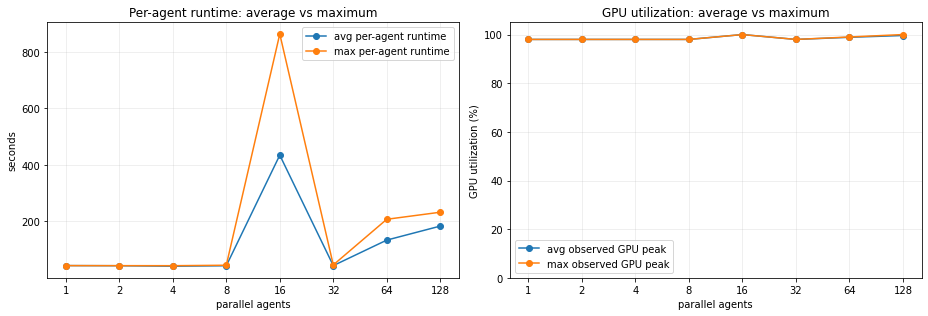

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(compare["batch_size"], compare["total_runtime_s_avg"], marker="o", label="avg per-agent runtime")
axes[0].plot(compare["batch_size"], compare["total_runtime_s_max"], marker="o", label="max per-agent runtime")
axes[0].set_title("Per-agent runtime: average vs maximum")
axes[0].set_xlabel("parallel agents")
axes[0].set_ylabel("seconds")
axes[0].set_xscale("log", base=2)
axes[0].set_xticks(compare["batch_size"])
axes[0].set_xticklabels(compare["batch_size"].astype(str))
axes[0].legend()

axes[1].plot(compare["batch_size"], compare["run_gpu_max_percent_avg"], marker="o", label="avg observed GPU peak")
axes[1].plot(compare["batch_size"], compare["run_gpu_max_percent_max"], marker="o", label="max observed GPU peak")
axes[1].set_title("GPU utilization: average vs maximum")
axes[1].set_xlabel("parallel agents")
axes[1].set_ylabel("GPU utilization (%)")
axes[1].set_ylim(0, 105)
axes[1].set_xscale("log", base=2)
axes[1].set_xticks(compare["batch_size"])
axes[1].set_xticklabels(compare["batch_size"].astype(str))
axes[1].legend()

fig.tight_layout()
plt.show()

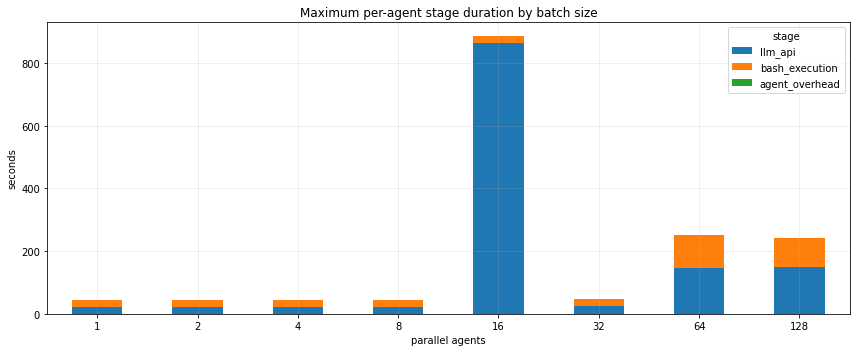

,llm_api,bash_execution,agent_overhead
batch_size,,,
1,21.505,21.785,0.011
2,20.765,22.314,0.013
4,21.036,21.981,0.013
8,21.574,23.061,0.014
16,863.536,22.287,0.025
32,23.337,23.204,0.015
64,147.244,104.047,0.046
128,150.478,90.469,0.064


In [13]:
stage_max = jobs_df.groupby("batch_size")[[f"{s}_duration_s" for s in STAGE_NAMES]].max()
stage_max.columns = [c.replace("_duration_s", "") for c in stage_max.columns]

ax = stage_max.plot(kind="bar", stacked=True, figsize=(12, 5), color=["tab:blue", "tab:orange", "tab:green"])
ax.set_title("Maximum per-agent stage duration by batch size")
ax.set_xlabel("parallel agents")
ax.set_ylabel("seconds")
ax.legend(title="stage")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

stage_max.round(3)

## Per-Job Distribution

Averages and maxima can hide spread. This plot shows every job runtime within each batch.

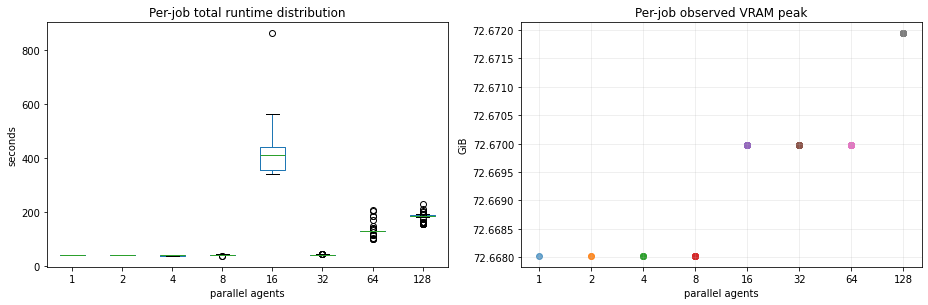

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

jobs_df.boxplot(column="total_runtime_s", by="batch_size", ax=axes[0], grid=False)
axes[0].set_title("Per-job total runtime distribution")
axes[0].set_xlabel("parallel agents")
axes[0].set_ylabel("seconds")

for batch, grp in jobs_df.groupby("batch_size"):
    axes[1].scatter(
        np.full(len(grp), batch),
        grp["run_vram_max_gib"],
        alpha=0.65,
        label=str(batch),
    )
axes[1].set_title("Per-job observed VRAM peak")
axes[1].set_xlabel("parallel agents")
axes[1].set_ylabel("GiB")
axes[1].set_xscale("log", base=2)
axes[1].set_xticks(sorted(jobs_df["batch_size"].unique()))
axes[1].set_xticklabels([str(x) for x in sorted(jobs_df["batch_size"].unique())])

fig.suptitle("")
fig.tight_layout()
plt.show()

## I/O and Network Summary

These are system-counter deltas observed during each job window. Because jobs overlap, these values should be interpreted as observed activity during a job, not exclusive ownership by that job.

In [15]:
io_compare = pd.DataFrame({
    "batch_size": batch_avg["batch_size"],
    "avg_disk_read_mib": batch_avg["run_disk_read_mib"],
    "max_disk_read_mib": batch_max["run_disk_read_mib"],
    "avg_disk_write_mib": batch_avg["run_disk_write_mib"],
    "max_disk_write_mib": batch_max["run_disk_write_mib"],
    "avg_net_sent_mib": batch_avg["run_net_sent_mib"],
    "max_net_sent_mib": batch_max["run_net_sent_mib"],
    "avg_net_recv_mib": batch_avg["run_net_recv_mib"],
    "max_net_recv_mib": batch_max["run_net_recv_mib"],
})
io_compare.round(3)

,batch_size,avg_disk_read_mib,max_disk_read_mib,avg_disk_write_mib,max_disk_write_mib,avg_net_sent_mib,max_net_sent_mib,avg_net_recv_mib,max_net_recv_mib
0,1,0.000,0.000,23.230,23.230,0.975,0.975,0.940,0.940
1,2,0.000,0.000,15.693,15.754,0.933,0.937,0.854,0.858
2,4,0.000,0.000,15.311,15.551,0.939,0.977,0.874,0.909
3,8,0.000,0.000,11.760,12.812,0.979,1.030,0.853,0.920
4,16,0.003,0.004,122.219,210.828,6.682,12.941,5.992,10.841
5,32,0.000,0.000,14.313,14.965,0.702,0.763,0.700,0.759
6,64,0.005,0.012,65.087,84.414,4.085,5.067,4.046,5.025
7,128,0.004,0.012,129.301,150.477,7.986,9.071,7.919,8.993


## Memory Usage (System RAM)

System RAM grows steadily as more agents run concurrently. Unlike VRAM (which is pinned by the model weights), host memory increases because every new agent process allocates its own Python heap, subprocess buffers, and tool-execution state.

- **Average view** – typical memory footprint seen by a single job in each batch.
- **Maximum view** – the peak observed across all jobs in the batch; use this for capacity planning.
- **Per-job scatter** – shows spread within each batch and highlights outliers (e.g., the high-runtime `batch_16` jobs).
- **Per-stage breakdown** – how RAM is split across the LLM-API call stage vs. bash execution vs. agent overhead.

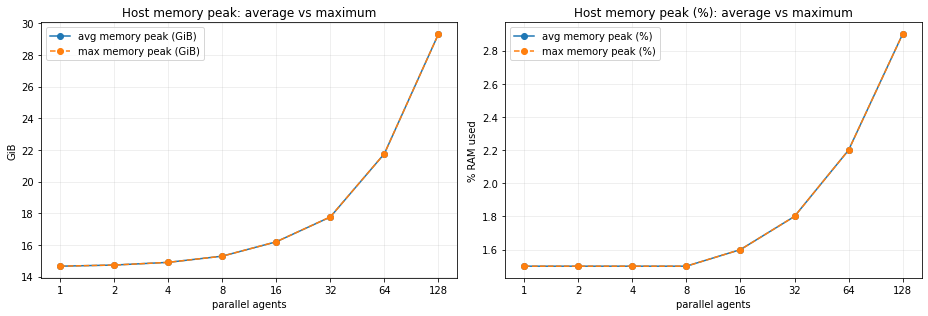

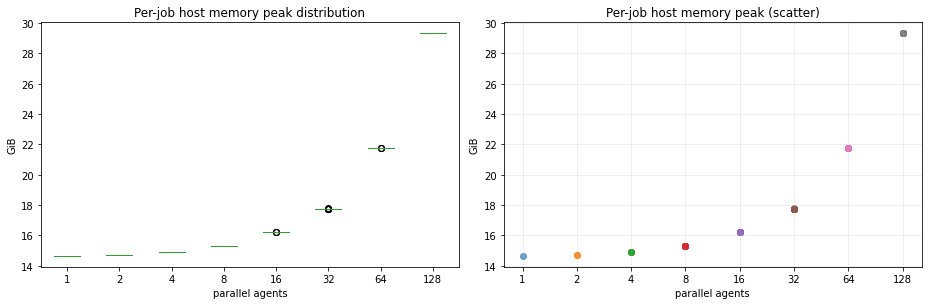

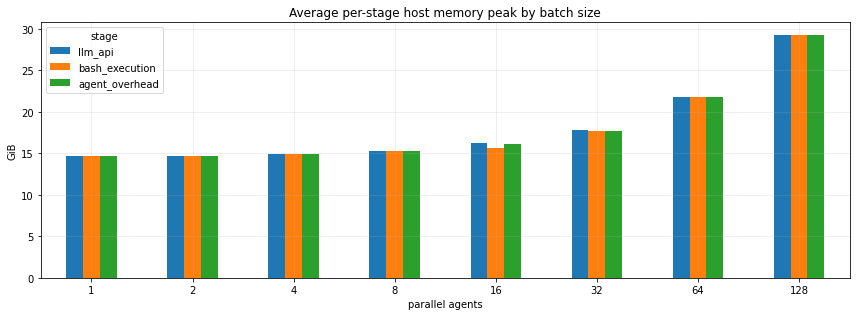

,batch_size,avg_memory_max_gib,max_memory_max_gib,avg_memory_max_pct,max_memory_max_pct
0,1,14.657,14.657,1.5,1.5
1,2,14.729,14.729,1.5,1.5
2,4,14.899,14.899,1.5,1.5
3,8,15.289,15.289,1.5,1.5
4,16,16.197,16.197,1.6,1.6
5,32,17.763,17.769,1.8,1.8
6,64,21.760,21.762,2.2,2.2
7,128,29.320,29.321,2.9,2.9


In [16]:
# ── 1. Average vs Maximum memory per batch ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(batch_avg["batch_size"], batch_avg["run_memory_max_gib"],
             marker="o", color="tab:blue", label="avg memory peak (GiB)")
axes[0].plot(batch_max["batch_size"], batch_max["run_memory_max_gib"],
             marker="o", linestyle="--", color="tab:orange", label="max memory peak (GiB)")
axes[0].set_title("Host memory peak: average vs maximum")
axes[0].set_xlabel("parallel agents")
axes[0].set_ylabel("GiB")
axes[0].set_xscale("log", base=2)
axes[0].set_xticks(batch_avg["batch_size"])
axes[0].set_xticklabels(batch_avg["batch_size"].astype(str))
axes[0].legend()

axes[1].plot(batch_avg["batch_size"], batch_avg["run_memory_max_percent"],
             marker="o", color="tab:blue", label="avg memory peak (%)")
axes[1].plot(batch_max["batch_size"], batch_max["run_memory_max_percent"],
             marker="o", linestyle="--", color="tab:orange", label="max memory peak (%)")
axes[1].set_title("Host memory peak (%): average vs maximum")
axes[1].set_xlabel("parallel agents")
axes[1].set_ylabel("% RAM used")
axes[1].set_xscale("log", base=2)
axes[1].set_xticks(batch_avg["batch_size"])
axes[1].set_xticklabels(batch_avg["batch_size"].astype(str))
axes[1].legend()

fig.tight_layout()
plt.show()

# ── 2. Per-job memory scatter ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

jobs_df.boxplot(column="run_memory_max_gib", by="batch_size", ax=axes[0], grid=False)
axes[0].set_title("Per-job host memory peak distribution")
axes[0].set_xlabel("parallel agents")
axes[0].set_ylabel("GiB")

for batch, grp in jobs_df.groupby("batch_size"):
    axes[1].scatter(
        np.full(len(grp), batch),
        grp["run_memory_max_gib"],
        alpha=0.65,
        label=str(batch),
    )
axes[1].set_title("Per-job host memory peak (scatter)")
axes[1].set_xlabel("parallel agents")
axes[1].set_ylabel("GiB")
axes[1].set_xscale("log", base=2)
axes[1].set_xticks(sorted(jobs_df["batch_size"].unique()))
axes[1].set_xticklabels([str(x) for x in sorted(jobs_df["batch_size"].unique())])

fig.suptitle("")
fig.tight_layout()
plt.show()

# ── 3. Per-stage memory breakdown (average) ────────────────────────────────
stage_mem_avg = jobs_df.groupby("batch_size")[[f"{s}_memory_max_gib" for s in STAGE_NAMES]].mean()
stage_mem_avg.columns = [c.replace("_memory_max_gib", "") for c in stage_mem_avg.columns]

ax = stage_mem_avg.plot(kind="bar", stacked=False, figsize=(12, 4.5),
                        color=["tab:blue", "tab:orange", "tab:green"])
ax.set_title("Average per-stage host memory peak by batch size")
ax.set_xlabel("parallel agents")
ax.set_ylabel("GiB")
ax.legend(title="stage")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ── 4. Summary table ────────────────────────────────────────────────────────
mem_summary = pd.DataFrame({
    "batch_size": batch_avg["batch_size"],
    "avg_memory_max_gib": batch_avg["run_memory_max_gib"].round(3),
    "max_memory_max_gib": batch_max["run_memory_max_gib"].round(3),
    "avg_memory_max_pct": batch_avg["run_memory_max_percent"].round(2),
    "max_memory_max_pct": batch_max["run_memory_max_percent"].round(2),
})
mem_summary

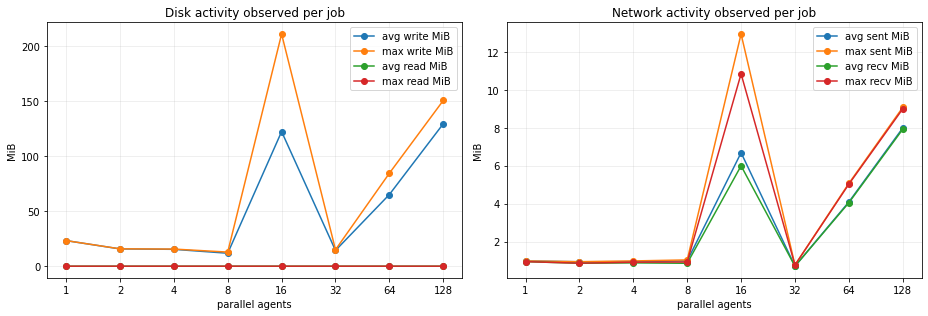

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(io_compare["batch_size"], io_compare["avg_disk_write_mib"], marker="o", label="avg write MiB")
axes[0].plot(io_compare["batch_size"], io_compare["max_disk_write_mib"], marker="o", label="max write MiB")
axes[0].plot(io_compare["batch_size"], io_compare["avg_disk_read_mib"], marker="o", label="avg read MiB")
axes[0].plot(io_compare["batch_size"], io_compare["max_disk_read_mib"], marker="o", label="max read MiB")
axes[0].set_title("Disk activity observed per job")
axes[0].set_xlabel("parallel agents")
axes[0].set_ylabel("MiB")
axes[0].set_xscale("log", base=2)
axes[0].set_xticks(io_compare["batch_size"])
axes[0].set_xticklabels(io_compare["batch_size"].astype(str))
axes[0].legend()

axes[1].plot(io_compare["batch_size"], io_compare["avg_net_sent_mib"], marker="o", label="avg sent MiB")
axes[1].plot(io_compare["batch_size"], io_compare["max_net_sent_mib"], marker="o", label="max sent MiB")
axes[1].plot(io_compare["batch_size"], io_compare["avg_net_recv_mib"], marker="o", label="avg recv MiB")
axes[1].plot(io_compare["batch_size"], io_compare["max_net_recv_mib"], marker="o", label="max recv MiB")
axes[1].set_title("Network activity observed per job")
axes[1].set_xlabel("parallel agents")
axes[1].set_ylabel("MiB")
axes[1].set_xscale("log", base=2)
axes[1].set_xticks(io_compare["batch_size"])
axes[1].set_xticklabels(io_compare["batch_size"].astype(str))
axes[1].legend()

fig.tight_layout()
plt.show()

## Save Derived Tables

The notebook writes CSV summaries next to the sweep directory so plots and tables can be reused without re-parsing every job JSON.

In [18]:
out_dir = SWEEP_DIR / "analysis_tables"
out_dir.mkdir(exist_ok=True)

jobs_df.to_csv(out_dir / "jobs_flat.csv", index=False)
batch_wall_df.to_csv(out_dir / "batch_wall_times.csv", index=False)
batch_avg.to_csv(out_dir / "batch_average_metrics.csv", index=False)
batch_max.to_csv(out_dir / "batch_max_metrics.csv", index=False)
compare.to_csv(out_dir / "batch_average_vs_max.csv", index=False)

print("wrote:")
for path in sorted(out_dir.glob("*.csv")):
    print("-", path.relative_to(REPO_ROOT))

wrote:
- benchmark_results/parallel_sweep_full_20260510_194911/analysis_tables/batch_average_metrics.csv
- benchmark_results/parallel_sweep_full_20260510_194911/analysis_tables/batch_average_vs_max.csv
- benchmark_results/parallel_sweep_full_20260510_194911/analysis_tables/batch_max_metrics.csv
- benchmark_results/parallel_sweep_full_20260510_194911/analysis_tables/batch_wall_times.csv
- benchmark_results/parallel_sweep_full_20260510_194911/analysis_tables/jobs_flat.csv


## Interpretation Notes

- `batch_wall_time_s` is the elapsed time for all jobs in that batch to finish.
- `total_runtime_s` is each individual agent/job's runtime; average and max are computed across jobs in the same batch.
- GPU and VRAM metrics are shared-system observations. With concurrent agents, a job's recorded GPU peak reflects the GPU state during that job's window, not exclusive per-agent usage.
- Use **average** tables for typical per-agent behavior.
- Use **maximum** tables for peak pressure and resource capacity analysis.
- If a batch looks anomalous, inspect the per-job rows in `jobs_df` and each job's `stdout.log`.